# 06 · Project — Generate gluon jets 🌫️

**Generative Modelling for HEP** — notebook 6 of 6 · *in-session mini project (~1.5h)*

You've built a VAE (01), a GAN (02) and diffusion models (03, 05). Time to put it
all together on a real problem.

### The goal
Generate **JetNet gluon jets** — point clouds of 30 particles, each
`(eta_rel, phi_rel, pt_rel)` — that look like the real thing. Use **any
architecture you like**: a VAE, a GAN, a diffusion model, or something hybrid.

### How you're scored
We measure a generator by the **jet-mass 1-Wasserstein distance**,
`src.jetmass.jet_mass_w1(real, generated)` — **lower is better**. The bulk of the
mass spectrum is easy; the sharp high-mass tail is hard — that's where the real
work is. At the end you'll **submit your jet-mass plot** so we can see how your
generator did.

### How this notebook works
- A small **baseline VAE** is trained for you, so you always have something to
  score and submit.
- The exercises take you from loading the data, to training a generator, to
  scoring and submitting your result, with a couple of reflective answers.
- **Scale-up ideas** are sprinkled through — go past the baseline if you have time!

You complete the cells marked **Exercise**. Everything else runs as-is.

In [1]:
%load_ext cadence
# Loads the cadence magics + the input transformer that comments out
# `# cadence:starter` regions, so the scaffold placeholders never run.

## Setup

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import sys; sys.path.insert(0, "..")
from src.seeds import set_seed
from src.train import get_device, to_loader, train
from src.data import load_jetnet
from src.gnn import DeepSetsEncoder, DeepSetsDecoder
from src.jetmass import jet_mass, plot_jet_mass, jet_mass_w1

# This project is scored on the REAL JetNet dataset — no synthetic fallback.
try:
    import jetnet  # noqa: F401
except ImportError as e:
    raise RuntimeError("This project needs the real JetNet dataset — install it with "
                       "`pip install jetnet` (it's in your class environment).") from e

SEED = 0
LATENT_DIM = 16
N_PARTICLES = 30
EPOCHS = 8            # small default; bump it once your generator works
BATCH = 128
set_seed(SEED)
device = get_device()
print(f"device={device}  latent_dim={LATENT_DIM}  epochs={EPOCHS}")

device=cpu  latent_dim=16  epochs=8


## Part A · Meet the data

Gluon jets have more, softer constituents than quark jets, which pushes their
**jet-mass** spectrum higher. We load the **real JetNet gluon jets** (this project
needs the real data — no synthetic stand-in), hold some out as a test set, and
look at the target mass distribution you're trying to match.

In [3]:
gluon = load_jetnet("g", num_particles=N_PARTICLES, max_jets=6000).astype(np.float32)

# A simple train/test split: train your generator on `train_jets`, always SCORE
# your W1 against the untouched `test_jets`.
n_test = 1500
test_jets = gluon[:n_test]
train_jets = gluon[n_test:]
jet_loader = to_loader(train_jets, batch_size=BATCH)

print("gluon jets:", gluon.shape,
      "| train:", train_jets.shape, "| test:", test_jets.shape)

[data] loaded 6000 real JetNet 'g' jets
gluon jets: (6000, 30, 3) | train: (4500, 30, 3) | test: (1500, 30, 3)


### Exercise 1 — Know your target

Before modelling anything, characterise the real gluon jets. Compute the
**median jet mass** of the held-out `test_jets` (using `jet_mass`) and return it
as `median_real_mass`, rounded to 4 dp.

This is the number your generated jets should cluster around — a quick gut-check
for later.

In [4]:
# cadence:checkpoint ex1-target
# cadence:starter
# characterise the real target: the MEDIAN jet mass of the held-out test_jets.
masses = ...
median_real_mass = ...
print("median real gluon jet mass:", median_real_mass)
# cadence:end
# cadence:hint masses = jet_mass(test_jets); median_real_mass = round(float(np.median(masses)), 4).

masses = jet_mass(test_jets)
median_real_mass = round(float(np.median(masses)), 4)
print("median real gluon jet mass:", median_real_mass)

median_real_mass

median real gluon jet mass: 0.05


0.05

## Part B · The baseline generator

Here is a small **DeepSets VAE** baseline, reusing the permutation-invariant GNN
blocks from notebook 01. It's intentionally modest so you have room to beat it.
We define it and train it for you below, then you'll improve and score it.

**Architecture (the baseline):**
- Encoder: `DeepSetsEncoder` → `(mu, logvar)` in latent space.
- Decoder: `DeepSetsDecoder` → a 30-particle cloud.
- Loss: per-feature reconstruction MSE + a small KL term.

**Scale-up ideas** (if you have time): widen `hidden`, raise `EPOCHS`, anneal the
KL weight, swap in a GAN critic for sharper tails, or try a diffusion decoder.

In [5]:
class BaselineVAE(nn.Module):
    def __init__(self, latent=LATENT_DIM, n_particles=N_PARTICLES):
        super().__init__()
        self.encoder = DeepSetsEncoder(in_features=3, hidden=128, latent=latent * 2)
        self.decoder = DeepSetsDecoder(latent=latent, n_particles=n_particles)
        self.latent = latent

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = h[:, :self.latent], h[:, self.latent:]
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decoder(z), mu, logvar

    @torch.no_grad()
    def sample(self, n):
        z = torch.randn(n, self.latent, device=next(self.parameters()).device)
        return self.decoder(z)


def vae_step(model, batch):
    x = batch[0]
    x_hat, mu, logvar = model(x)
    recon = F.mse_loss(x_hat, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + 1e-3 * kl


model = BaselineVAE().to(device)
print("baseline params:", sum(p.numel() for p in model.parameters()))

baseline params: 59267


### Exercise 2 — Train your generator

Train the baseline (or your own improved version!) and look at its final-epoch
loss. `train(model, loader, step_fn, epochs=..., lr=..., device=...)` returns the
per-epoch loss history; the provided `vae_step` is the baseline objective. If you
build a different model, pass its own step function instead. Run it, then mark it
done — the loss scale depends on your architecture, so this one's on your honour.

In [6]:
# cadence:checkpoint ex2-train manual
# cadence:given
history = train(model, jet_loader, vae_step, epochs=EPOCHS, lr=1e-3, device=device)
final_loss = round(float(history[-1]), 4)
print("final training loss:", final_loss)
# cadence:end
# cadence:starter
# The baseline trains above. Swap in your own model + step function if you built
# one, then run this cell and mark it done.
# cadence:end

train:   0%|          | 0/8 [00:00<?, ?it/s]

/Users/liv/teaching/ml4hep/gen-hep-notebooks/notebooks/../src/train.py:48: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  running += float(loss) * (len(batch[0]) if isinstance(batch, (list, tuple)) else len(batch))


final training loss: 0.0042


### Exercise 3 — Score and submit your result

The headline. **Generate** as many jets as the test set, **plot** the jet-mass
overlay (real gluon vs your generated jets — the recurring spine), compute your
score `mass_w1 = jet_mass_w1(test_jets, gen)` (**lower is better**), and
**`submit_image`** the plot so the teacher can see how your generator did.

The baseline gets the bulk roughly right but smears the high-mass tail — look at
the overlay, see where it's off, then come back and improve the model to drive
`mass_w1` down.

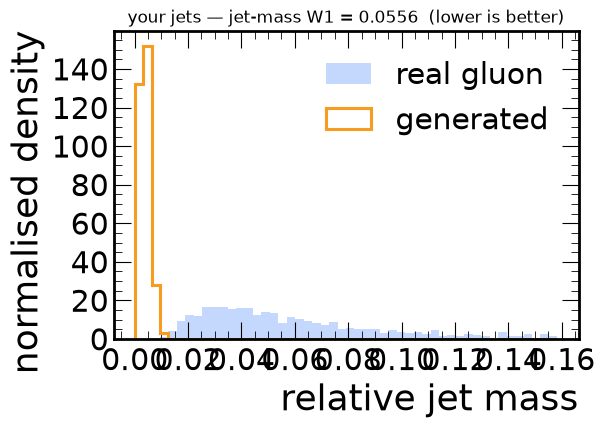

your jet-mass W1: 0.0556


In [7]:
# cadence:checkpoint ex3-submit manual
# cadence:given
model.eval()
with torch.no_grad():
    gen = model.sample(len(test_jets)).cpu().numpy()   # or samples from your own model
ax = plot_jet_mass(test_jets, gen, labels=("real gluon", "generated"))
mass_w1 = round(jet_mass_w1(test_jets, gen), 4)
ax.set_title(f"your jets — jet-mass W1 = {mass_w1}  (lower is better)")
fig = ax.get_figure(); plt.show()
print("your jet-mass W1:", mass_w1)
# cadence:end
# cadence:starter
# submit your jet-mass plot for the teacher to see:
submit_image("ex3-submit", fig)
# cadence:end

## Part C · Reflect & report

Two quick answers to wrap up your submission: which family of model you went
with, and a snapshot of your generated mass spectrum.

### Exercise 4 — Declare your architecture

Which generative family did your submitted model belong to? Set `model_choice` to
one of `"vae"`, `"gan"` or `"diffusion"` (the baseline is a VAE — change it if you
swapped it out), then run to record it.

In [8]:
# cadence:checkpoint ex4-architecture manual
# cadence:starter
model_choice = "vae"   # "vae", "gan", or "diffusion" — whatever you actually used
# cadence:end

### Exercise 5 — Summarise your generated mass (reflection)

The cell computes the **mean** and **standard deviation** of your generated jet
mass. Compare them to `median_real_mass` (Exercise 1), then write 2–3 sentences
and submit:

- Is your generated mass centred near the real median, or shifted?
- Is your std much *smaller* than the real jets' spread — the classic "too blurry
  / mode-dropping" tell? What would you change to fix it?

In [9]:
# cadence:checkpoint ex5-summary manual
# cadence:given
gen_masses = jet_mass(gen)
print("generated mass [mean, std]:",
      [round(float(np.mean(gen_masses)), 4), round(float(np.std(gen_masses)), 4)])
print("real median (Exercise 1):", median_real_mass)
# cadence:end
# cadence:starter
# Your reflection (2-3 sentences), then run the cell to submit:
#   * is your generated mass centred near the real median, or shifted?
#   * is the std too small (the "too blurry" tell), and what would you change?
# cadence:end

generated mass [mean, std]: [0.0038, 0.0019]
real median (Exercise 1): 0.05


## Wrap-up

- You generated gluon jets end-to-end and scored them on a single, honest metric:
  the **jet-mass 1-Wasserstein distance**.
- The baseline VAE gets the bulk roughly right but smears the **high-mass tail** —
  the recurring lesson of these notebooks.
- **To drive `mass_w1` down:** train longer, widen the networks, anneal the KL, or
  bring in a GAN critic / diffusion decoder for sharper tails. The metric tells you
  honestly whether it helped.

Nice work — that's the full arc from VAE to GAN to diffusion to your own
generator. 🎉

<!-- cadence:hide -->
## Generate the cadence notebooks

Run this **after** *Run All* above, so every exercise's answer value is in the kernel. `%cadence_autoregister` auto-detects each `##`-headed exercise, registers a checkpoint from the cell's final value, and writes `<this>_registered.ipynb` — which in turn writes the student notebook via the `%cadence_scaffold` cell it appends.
<!-- cadence:end -->

In [10]:
%cadence_autoregister --reveal-after 4

id,comparator,expected
ex1-target,numeric,0.05
ex2-train,manual,—
ex3-submit,manual,—
ex4-architecture,manual,—
ex5-summary,manual,—


/Users/liv/teaching/ml4hep/gen-hep-notebooks/notebooks/06_project_registered.ipynb